# Baseline Road Deterioration Models (v2)

This notebook trains and evaluates simple baseline models for next-measurement prediction.

Changes from v1:
- Added `current_lag_static` feature set: lag features + static road attributes, without lifecycle features.
  This isolates whether static features help independently of lifecycle context.
- Added cells for 1-, 2-, 3- and 4-year horizon prediction.

Current scope:
- Persistence baseline
- Linear regression
- Ridge regression

Targets:
- `target_next_URA`
- `target_next_IRI`

Rows represent current PTM measurements, and targets are the next PTM measurement within the same lifecycle.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
DATA_PATH = Path("data/road_model_dataset_v1.parquet")
RANDOM_STATE = 42

# To keep the notebook responsive, models are fit on sampled subsets.
# Increase these later if you want to push performance further.
TRAIN_SAMPLE_N = 250_000
TEST_SAMPLE_N = 100_000

# Use the first 80% of unique dates for training and the last 20% for testing.
TRAIN_DATE_QUANTILE = 0.80

In [3]:
use_cols = [
    "Segment_ID",
    "Lifecycle_ID",
    "event_date",
    "KVL",
    "KVL_raskas",
    "KVL_kaista",
    "Nopeus",
    "Toim_lk",
    "Pituus",
    "IRI",
    "URA",
    "Pavement_Age_years",
    "Initial_URA",
    "Measurement_Idx",
    "Minor_TP_Count",
    "tp_count_interval",
    "has_TP_interval",
    "prev_IRI",
    "prev_URA",
    "Delta_t_days",
    "Delta_t_years",
    "target_next_URA",
    "target_next_IRI",
    "target_next_event_date",
    "target_horizon_days",
    "baseline_persist_URA",
    "baseline_persist_IRI",
]

df = pd.read_parquet(DATA_PATH, columns=use_cols)
df["event_date"] = pd.to_datetime(df["event_date"])
df["target_next_event_date"] = pd.to_datetime(df["target_next_event_date"])

print(df.shape)
display(df.head())
print(df[["event_date", "target_next_event_date"]].agg(["min", "max"]))

(3833323, 27)


,Segment_ID,Lifecycle_ID,event_date,KVL,KVL_raskas,KVL_kaista,Nopeus,Toim_lk,Pituus,IRI,URA,Pavement_Age_years,Initial_URA,Measurement_Idx,Minor_TP_Count,tp_count_interval,has_TP_interval,prev_IRI,prev_URA,Delta_t_days,Delta_t_years,target_next_URA,target_next_IRI,target_next_event_date,target_horizon_days,baseline_persist_URA,baseline_persist_IRI
0,Epo_13309_0_11_3_6900_3_7000,Epo_13309_0_11_3_6900_3_7000_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,1.60,2.7,0.0,2.7,1,1,1,True,NaN,NaN,NaN,NaN,2.7,1.93,2022-08-23,1527.0,2.7,1.60
1,Epo_13309_0_11_3_7000_3_7100,Epo_13309_0_11_3_7000_3_7100_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,1.50,1.4,0.0,1.4,1,1,1,True,NaN,NaN,NaN,NaN,1.7,1.70,2022-08-23,1527.0,1.4,1.50
2,Epo_13309_0_11_3_7100_3_7200,Epo_13309_0_11_3_7100_3_7200_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,1.75,1.5,0.0,1.5,1,1,1,True,NaN,NaN,NaN,NaN,1.5,1.91,2022-08-23,1527.0,1.5,1.75
3,Epo_13309_0_11_3_7200_3_7300,Epo_13309_0_11_3_7200_3_7300_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,1.45,4.7,0.0,4.7,1,1,1,True,NaN,NaN,NaN,NaN,3.5,1.66,2022-08-23,1527.0,4.7,1.45
4,Epo_13309_0_11_3_7300_3_7400,Epo_13309_0_11_3_7300_3_7400_C0,2018-06-18,182.0,23.0,80.0,80,yhdys,100,2.42,1.4,0.0,1.4,1,1,1,True,NaN,NaN,NaN,NaN,2.0,2.96,2022-08-23,1527.0,1.4,2.42


    event_date target_next_event_date
min 2005-05-19             2011-04-08
max 2023-09-06             2024-09-23


### Next measurement prediction
Run ONLY this (ignore the next cell) if you want to predict the next measurement.

In [ ]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df.loc[df["event_date"] < cutoff_date].copy()
test_df = df.loc[df["event_date"] >= cutoff_date].copy()


print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Train date range: {train_df['event_date'].min().date()} -> {train_df['event_date'].max().date()}")
print(f"Test date range: {test_df['event_date'].min().date()} -> {test_df['event_date'].max().date()}")

Cutoff date: 2020-08-18
Train rows: 3,096,068
Test rows: 737,255
Train date range: 2005-05-19 -> 2020-08-17
Test date range: 2020-08-18 -> 2023-09-06


### 1-year horizon prediction

In [4]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df.loc[df["event_date"] < cutoff_date].copy()
test_df = df.loc[df["event_date"] >= cutoff_date].copy()

# Filter to 1-year horizon
train_df = train_df[train_df["target_horizon_days"].between(274, 457)].copy()
test_df = test_df[test_df["target_horizon_days"].between(274, 457)].copy()

print(f"1-year horizon train rows: {len(train_df):,}")
print(f"1-year horizon test rows: {len(test_df):,}")


print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Train date range: {train_df['event_date'].min().date()} -> {train_df['event_date'].max().date()}")
print(f"Test date range: {test_df['event_date'].min().date()} -> {test_df['event_date'].max().date()}")

1-year horizon train rows: 1,434,070
1-year horizon test rows: 394,688
Cutoff date: 2020-08-18
Train rows: 1,434,070
Test rows: 394,688
Train date range: 2010-04-09 -> 2020-08-17
Test date range: 2020-08-18 -> 2023-09-03


In [5]:
def sample_rows(frame: pd.DataFrame, n: int, random_state: int) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n=n, random_state=random_state).copy()


train_sample = sample_rows(train_df, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample = sample_rows(test_df, TEST_SAMPLE_N, RANDOM_STATE)

print(f"Train sample rows: {len(train_sample):,}")
print(f"Test sample rows: {len(test_sample):,}")

Train sample rows: 250,000
Test sample rows: 100,000


In [6]:
def regression_metrics(y_true, y_pred, model_name, target_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        "model": model_name,
        "target": target_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_true, y_pred),
    }


results = []

In [7]:
# Persistence baseline
results.append(
    regression_metrics(
        test_sample["target_next_URA"],
        test_sample["baseline_persist_URA"],
        "persistence",
        "target_next_URA",
    )
)

results.append(
    regression_metrics(
        test_sample["target_next_IRI"],
        test_sample["baseline_persist_IRI"],
        "persistence",
        "target_next_IRI",
    )
)

pd.DataFrame(results)

,model,target,mae,rmse,r2
0,persistence,target_next_URA,1.890712,2.407464,0.695640
1,persistence,target_next_IRI,0.147781,0.305405,0.766435


In [8]:
# feature_cols = [
#     "URA",
#     "IRI",
#     "prev_URA",
#     "prev_IRI",
#     "Delta_t_days",
#     "Delta_t_years",
#     "Pavement_Age_years",
#     "Initial_URA",
#     "Measurement_Idx",
#     "Minor_TP_Count",
#     "tp_count_interval",
#     "has_TP_interval",
#     "KVL",
#     "KVL_raskas",
#     "KVL_kaista",
#     "Nopeus",
#     "Pituus",
#     "Toim_lk",
# ]
feature_cols = [
    "URA",
    "IRI",
    "prev_URA",
    "prev_IRI",
    "Delta_t_years",
    "Pavement_Age_years",
    "Initial_URA",
    "Measurement_Idx",
    "Minor_TP_Count",
    "tp_count_interval",
    "has_TP_interval",
    "KVL",
    "KVL_raskas",
    "KVL_kaista",
    "Nopeus",
    "Toim_lk",
]


numeric_features = [c for c in feature_cols if c != "Toim_lk"]
categorical_features = ["Toim_lk"]

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", one_hot),
                ]
            ),
            categorical_features,
        ),
    ]
)

models = {
    "linear_regression": LinearRegression(),
    "ridge_alpha_1": Ridge(alpha=1.0),
}

predictions = {}

In [9]:
for target_name in ["target_next_URA", "target_next_IRI"]:
    train_target = train_sample[target_name].notna()
    test_target = test_sample[target_name].notna()

    X_train = train_sample.loc[train_target, feature_cols]
    y_train = train_sample.loc[train_target, target_name]
    X_test = test_sample.loc[test_target, feature_cols]
    y_test = test_sample.loc[test_target, target_name]

    for model_name, estimator in models.items():
        pipe = Pipeline(
            steps=[
                ("preprocess", preprocess),
                ("model", estimator),
            ]
        )
        # print(feature_cols)
        # print(numeric_features)
        # print(categorical_features)
        # print(X_train.shape)
        # print(X_train.columns.tolist())


        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results.append(regression_metrics(y_test, y_pred, model_name, target_name))
        predictions[(model_name, target_name)] = (y_test, y_pred)

results_df = pd.DataFrame(results).sort_values(["target", "mae", "rmse"]).reset_index(drop=True)
results_df

,model,target,mae,rmse,r2
0,linear_regression,target_next_IRI,0.147158,0.288442,0.791661
1,ridge_alpha_1,target_next_IRI,0.147159,0.288442,0.791660
2,persistence,target_next_IRI,0.147781,0.305405,0.766435
3,linear_regression,target_next_URA,1.072000,1.548918,0.874013
4,ridge_alpha_1,target_next_URA,1.072001,1.548918,0.874013
5,persistence,target_next_URA,1.890712,2.407464,0.695640


In [10]:
summary_table = results_df.pivot(index="model", columns="target", values=["mae", "rmse", "r2"])
summary_table

mae                            rmse                              r2                
target            target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
model                                                                                                            
linear_regression        0.147158        1.072000        0.288442        1.548918        0.791661        0.874013
persistence              0.147781        1.890712        0.305405        2.407464        0.766435        0.695640
ridge_alpha_1            0.147159        1.072001        0.288442        1.548918        0.791660        0.874013

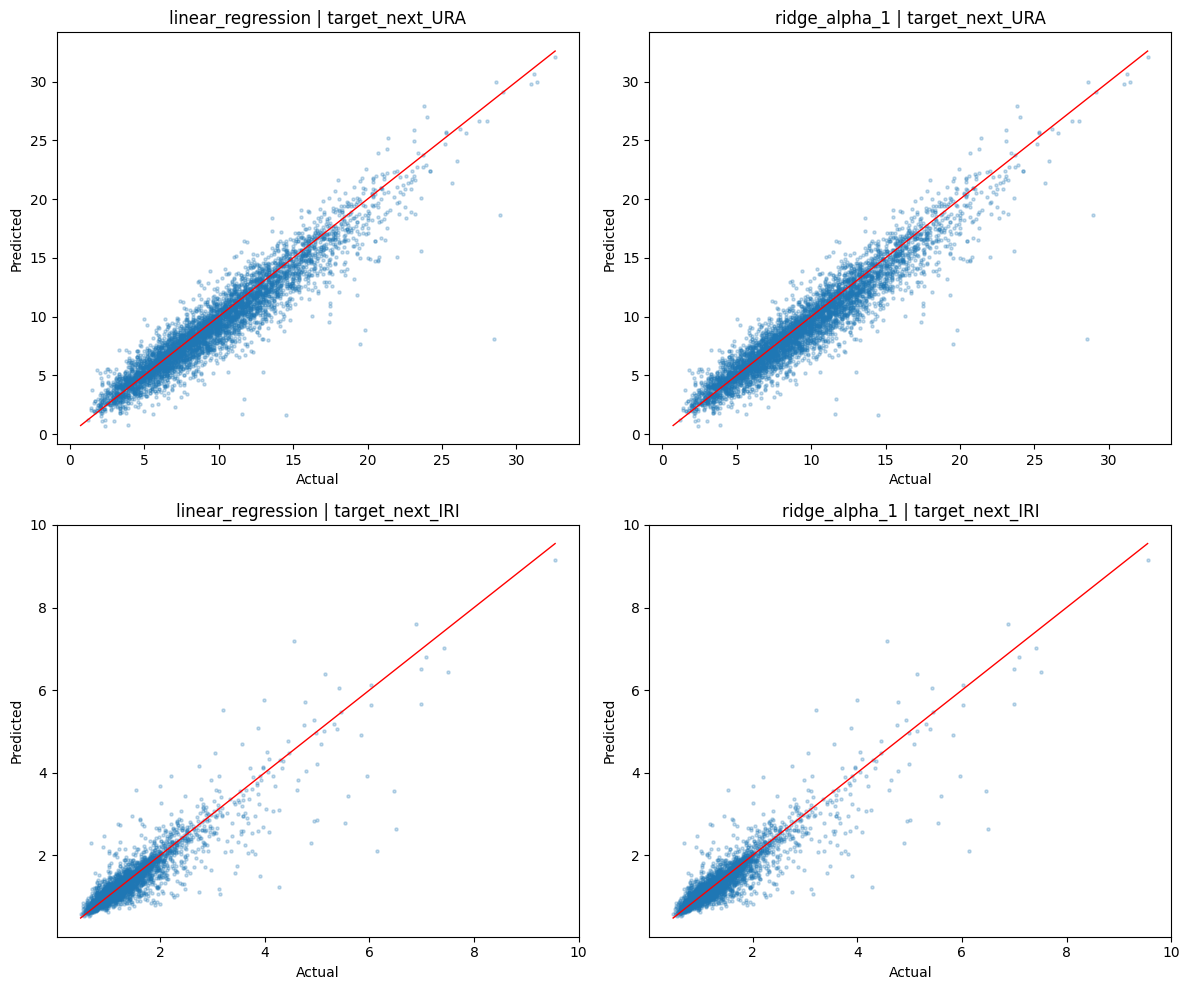

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_targets = ["target_next_URA", "target_next_IRI"]
plot_models = ["linear_regression", "ridge_alpha_1"]

for row_idx, target_name in enumerate(plot_targets):
    for col_idx, model_name in enumerate(plot_models):
        ax = axes[row_idx, col_idx]
        y_true, y_pred = predictions[(model_name, target_name)]

        plot_df = pd.DataFrame({"actual": y_true, "predicted": y_pred}).sample(
            n=min(5000, len(y_true)),
            random_state=RANDOM_STATE,
        )

        ax.scatter(plot_df["actual"], plot_df["predicted"], s=5, alpha=0.25)
        lo = min(plot_df["actual"].min(), plot_df["predicted"].min())
        hi = max(plot_df["actual"].max(), plot_df["predicted"].max())
        ax.plot([lo, hi], [lo, hi], color="red", linewidth=1)
        ax.set_title(f"{model_name} | {target_name}")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")

plt.tight_layout()

## Feature Ablation

This section compares nested feature groups for the linear models so we can see where the predictive signal comes from.

In [12]:
def split_valid_feature_groups(frame: pd.DataFrame, selected_features):
    available = [c for c in selected_features if c in frame.columns]
    non_empty = [c for c in available if frame[c].notna().any()]
    dropped_all_missing = [c for c in available if c not in non_empty]
    numeric_features = [c for c in non_empty if c != "Toim_lk"]
    categorical_features = [c for c in ["Toim_lk"] if c in non_empty]
    return {
        "available": available,
        "non_empty": non_empty,
        "dropped_all_missing": dropped_all_missing,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }


def build_preprocessor(feature_groups):
    numeric_features = feature_groups["numeric_features"]
    categorical_features = feature_groups["categorical_features"]
    transformers = []

    if numeric_features:
        transformers.append(
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            )
        )

    if categorical_features:
        try:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
        except TypeError:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse=True)

        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", one_hot),
                    ]
                ),
                categorical_features,
            )
        )

    if not transformers:
        raise ValueError("No valid non-empty feature columns were found for preprocessing.")

    return ColumnTransformer(transformers=transformers)


feature_sets = {
    "current_only": [
        "URA",
        "IRI",
    ],
    "current_plus_lag": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
    ],
    "current_lag_static": [
        "URA", "IRI",
        "prev_URA", "prev_IRI", "Delta_t_years",
        "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    ],
    "current_lag_lifecycle": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
        "Pavement_Age_years",
        "Initial_URA",
        "Measurement_Idx",
        "Minor_TP_Count",
        "tp_count_interval",
        "has_TP_interval",
    ],
    "current_lag_lifecycle_static": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
        "Pavement_Age_years",
        "Initial_URA",
        "Measurement_Idx",
        "Minor_TP_Count",
        "tp_count_interval",
        "has_TP_interval",
        "KVL",
        "KVL_raskas",
        "KVL_kaista",
        "Nopeus",
        "Toim_lk",
    ],
}

ablation_models = {
    "linear_regression": LinearRegression(),
    "ridge_alpha_1": Ridge(alpha=1.0),
}

ablation_results = []
ablation_predictions = {}
linear_model_fits = {}

In [13]:
for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== Feature set: {feature_set_name} ===")

    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample[target_name].notna()
        test_target = test_sample[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample.columns]
        X_train = train_sample.loc[train_target, active_features].copy()
        y_train = train_sample.loc[train_target, target_name]
        X_test = test_sample.loc[test_target, active_features].copy()
        y_test = test_sample.loc[test_target, target_name]

        train_feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(train_feature_groups)

        print(f"Target: {target_name}")
        print(f"Requested features: {active_features}")
        print(f"Dropped all-missing features: {train_feature_groups['dropped_all_missing']}")

        for model_name, estimator in ablation_models.items():
            pipe = Pipeline(
                steps=[
                    ("preprocess", build_preprocessor(train_feature_groups)),
                    ("model", clone(estimator)),
                ]
            )

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            metrics = regression_metrics(y_test, y_pred, model_name, target_name)
            metrics["feature_set"] = feature_set_name
            metrics["n_features_requested"] = len(active_features)
            metrics["n_features_used"] = len(train_feature_groups["non_empty"])
            ablation_results.append(metrics)

            ablation_predictions[(feature_set_name, model_name, target_name)] = (y_test, y_pred)
            linear_model_fits[(feature_set_name, model_name, target_name)] = pipe

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    ["target", "feature_set", "mae", "rmse"]
).reset_index(drop=True)
ablation_results_df


=== Feature set: current_only ===
Target: target_next_URA
Requested features: ['URA', 'IRI']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI']
Dropped all-missing features: []

=== Feature set: current_plus_lag ===
Target: target_next_URA
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years']
Dropped all-missing features: []

=== Feature set: current_lag_static ===
Target: target_next_URA
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years', 'KVL', 'KVL_raskas', 'KVL_kaista', 'Nopeus', 'Toim_lk']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years', 'KVL', 'KVL_raskas', 'KVL_kaista', 'Nopeus', 'Toim_lk']
Dropped all-missing features: []

=== Feature set: current_lag_lifecycle ===
Target: targe

,model,target,mae,rmse,r2,feature_set,n_features_requested,n_features_used
0,linear_regression,target_next_IRI,0.146498,0.289122,0.790677,current_lag_lifecycle,11,11
1,ridge_alpha_1,target_next_IRI,0.146498,0.289122,0.790677,current_lag_lifecycle,11,11
2,linear_regression,target_next_IRI,0.147158,0.288442,0.791661,current_lag_lifecycle_static,16,16
3,ridge_alpha_1,target_next_IRI,0.147159,0.288442,0.791660,current_lag_lifecycle_static,16,16
4,linear_regression,target_next_IRI,0.147077,0.288922,0.790966,current_lag_static,10,10
5,ridge_alpha_1,target_next_IRI,0.147078,0.288923,0.790966,current_lag_static,10,10
6,linear_regression,target_next_IRI,0.149940,0.294508,0.782805,current_only,2,2
7,ridge_alpha_1,target_next_IRI,0.149940,0.294508,0.782805,current_only,2,2
8,linear_regression,target_next_IRI,0.147514,0.289987,0.789424,current_plus_lag,5,5
9,ridge_alpha_1,target_next_IRI,0.147515,0.289987,0.789423,current_plus_lag,5,5


In [14]:
ablation_summary = ablation_results_df.pivot_table(
    index=["feature_set", "model"],
    columns="target",
    values=["mae", "rmse", "r2"],
)
ablation_summary

mae                              r2                            rmse                
target                                         target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
feature_set                  model                                                                                                            
current_lag_lifecycle        linear_regression        0.146498        1.147826        0.790677        0.858764        0.289122        1.639979
                             ridge_alpha_1            0.146498        1.147825        0.790677        0.858765        0.289122        1.639977
current_lag_lifecycle_static linear_regression        0.147158        1.072000        0.791661        0.874013        0.288442        1.548918
                             ridge_alpha_1            0.147159        1.072001        0.791660        0.874013        0.288442        1.548918
current_lag_static           linear_regression        0.147077        1.059514        0.790966        0.876494        0.288922        1.533593
                             ridge_alpha_1            0.147078        1.059514        0.790966        0.876494        0.288923        1.533593
current_only                 linear_regression        0.149940        1.170732        0.782805        0.853244        0.294508        1.671724
                             ridge_alpha_1            0.149940        1.170732        0.782805        0.853244        0.294508        1.671724
current_plus_lag             linear_regression        0.147514        1.143199        0.789424        0.859907        0.289987        1.633330
                             ridge_alpha_1            0.147515        1.143199        0.789423        0.859907        0.289987        1.633330

## Linear Coefficient Inspection

These cells inspect the fitted coefficients for the linear models. Because preprocessing includes scaling and one-hot encoding, the coefficients are shown in transformed-feature space.

In [15]:
def get_transformed_feature_names(pipe):
    preprocess = pipe.named_steps["preprocess"]
    try:
        return preprocess.get_feature_names_out()
    except AttributeError:
        feature_names = []
        for name, transformer, cols in preprocess.transformers_:
            if name == "remainder":
                continue
            if hasattr(transformer, "get_feature_names_out"):
                feature_names.extend(transformer.get_feature_names_out(cols))
            else:
                feature_names.extend(cols)
        return np.array(feature_names)


def coefficient_table(pipe):
    model = pipe.named_steps["model"]
    feature_names = get_transformed_feature_names(pipe)
    coef = np.ravel(model.coef_)
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coef,
    })
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    return coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)


best_linear_keys = {}
for target_name in ["target_next_URA", "target_next_IRI"]:
    target_rows = ablation_results_df.loc[
        (ablation_results_df["target"] == target_name)
        & (ablation_results_df["model"] == "linear_regression")
    ].sort_values("rmse")
    best_row = target_rows.iloc[0]
    best_linear_keys[target_name] = (
        best_row["feature_set"],
        best_row["model"],
        target_name,
    )

best_linear_keys

{'target_next_URA': ('current_lag_static',
  'linear_regression',
  'target_next_URA'),
 'target_next_IRI': ('current_lag_lifecycle_static',
  'linear_regression',
  'target_next_IRI')}

In [16]:
for target_name, fit_key in best_linear_keys.items():
    print(f"\nTop coefficients for {target_name} using {fit_key[0]}:")
    display(coefficient_table(linear_model_fits[fit_key]).head(20))


Top coefficients for target_next_URA using current_lag_static:


,feature,coefficient,abs_coefficient
0,num__URA,3.824900,3.824900
1,num__KVL_kaista,0.663399,0.663399
2,num__prev_URA,0.166500,0.166500
3,cat__Toim_lk_valta,0.162413,0.162413
4,num__KVL,-0.162338,0.162338
5,cat__Toim_lk_yhdys,-0.159366,0.159366
6,num__prev_IRI,0.114525,0.114525
7,num__IRI,-0.100040,0.100040
8,num__Nopeus,-0.072275,0.072275
9,cat__Toim_lk_seutu,-0.064900,0.064900



Top coefficients for target_next_IRI using current_lag_lifecycle_static:


,feature,coefficient,abs_coefficient
0,num__IRI,0.623090,0.623090
1,num__prev_IRI,0.147194,0.147194
2,cat__Toim_lk_yhdys,0.051658,0.051658
3,num__URA,0.047316,0.047316
4,cat__Toim_lk_valta,-0.037257,0.037257
5,num__Measurement_Idx,-0.023263,0.023263
6,num__prev_URA,-0.018787,0.018787
7,cat__Toim_lk_kanta,-0.015778,0.015778
8,num__has_TP_interval,-0.015359,0.015359
9,num__Pavement_Age_years,0.014876,0.014876


## Notes for next iteration

- Compare whether static variables actually improve over current-condition persistence.
- Try a reduced feature set with only current value and delta-time first.
- If linear models underperform persistence, the next step should be a tree-based baseline such as `HistGradientBoostingRegressor`.
- Later, add richer lifecycle-history features or explicit TP-event history.

### 2-year horizon prediction

In [17]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_2yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_2yr = df.loc[df["event_date"] >= cutoff_date].copy()

# Filter to 2-year horizon (±3 months)
train_df_2yr = train_df_2yr[train_df_2yr["target_horizon_days"].between(639, 822)].copy()
test_df_2yr = test_df_2yr[test_df_2yr["target_horizon_days"].between(639, 822)].copy()

print(f"2-year horizon train rows: {len(train_df_2yr):,}")
print(f"2-year horizon test rows:  {len(test_df_2yr):,}")
print(f"Mean horizon days: {train_df_2yr['target_horizon_days'].mean():.1f}")


2-year horizon train rows: 300,241
2-year horizon test rows:  133,130
Mean horizon days: 728.3


In [18]:
train_sample_2yr = sample_rows(train_df_2yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_2yr  = sample_rows(test_df_2yr,  TEST_SAMPLE_N,  RANDOM_STATE)

print(f"Train sample: {len(train_sample_2yr):,}  Test sample: {len(test_sample_2yr):,}")


Train sample: 250,000  Test sample: 100,000


In [19]:
results_2yr = []

# Persistence baseline
results_2yr.append(regression_metrics(test_sample_2yr["target_next_URA"], test_sample_2yr["baseline_persist_URA"], "persistence", "target_next_URA"))
results_2yr.append(regression_metrics(test_sample_2yr["target_next_IRI"], test_sample_2yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

# Linear models — ablation over feature sets
ablation_results_2yr = []
for feature_set_name, selected_features in feature_sets.items():
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_2yr[target_name].notna()
        test_target  = test_sample_2yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_2yr.columns]
        X_train = train_sample_2yr.loc[train_target, active_features].copy()
        y_train = train_sample_2yr.loc[train_target, target_name]
        X_test  = test_sample_2yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_2yr.loc[test_target,  target_name]

        train_feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(train_feature_groups)

        for model_name, estimator in ablation_models.items():
            from sklearn.base import clone
            from sklearn.pipeline import Pipeline
            pipe = Pipeline(steps=[("preprocess", build_preprocessor(train_feature_groups)), ("model", clone(estimator))])
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            m = regression_metrics(y_test, y_pred, model_name, target_name)
            m["feature_set"] = feature_set_name
            ablation_results_2yr.append(m)

ablation_df_2yr = (
    pd.DataFrame(ablation_results_2yr)
    .sort_values(["target", "feature_set", "rmse"])
    .reset_index(drop=True)
)

# Summary table
summary_2yr = ablation_df_2yr.pivot_table(
    index=["feature_set", "model"], columns="target", values=["mae", "rmse", "r2"]
)

print("\n=== 2-year horizon — ablation results ===")
display(summary_2yr)

print("\n=== 2-year horizon — persistence baseline ===")
display(pd.DataFrame(results_2yr))



=== 2-year horizon — ablation results ===


mae                              r2                            rmse                
target                                         target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
feature_set                  model                                                                                                            
current_lag_lifecycle        linear_regression        0.225623        1.358367        0.830947        0.827833        0.368019        1.859993
                             ridge_alpha_1            0.225623        1.358366        0.830947        0.827833        0.368019        1.859990
current_lag_lifecycle_static linear_regression        0.229481        1.277694        0.830182        0.843354        0.368851        1.774170
                             ridge_alpha_1            0.229482        1.277694        0.830182        0.843355        0.368851        1.774169
current_lag_static           linear_regression        0.229422        1.247509        0.829251        0.848821        0.369861        1.742936
                             ridge_alpha_1            0.229423        1.247510        0.829250        0.848821        0.369861        1.742937
current_only                 linear_regression        0.223044        1.317588        0.828769        0.835371        0.370383        1.818817
                             ridge_alpha_1            0.223044        1.317588        0.828769        0.835371        0.370383        1.818816
current_plus_lag             linear_regression        0.225122        1.319082        0.829683        0.835418        0.369392        1.818560
                             ridge_alpha_1            0.225122        1.319082        0.829683        0.835418        0.369392        1.818560


=== 2-year horizon — persistence baseline ===


,model,target,mae,rmse,r2
0,persistence,target_next_URA,2.381855,2.904338,0.580220
1,persistence,target_next_IRI,0.237709,0.400372,0.799917


### 3-year horizon prediction

In [20]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_3yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_3yr = df.loc[df["event_date"] >= cutoff_date].copy()

# Filter to 3-year horizon (±3 months)
train_df_3yr = train_df_3yr[train_df_3yr["target_horizon_days"].between(1004, 1187)].copy()
test_df_3yr = test_df_3yr[test_df_3yr["target_horizon_days"].between(1004, 1187)].copy()

print(f"3-year horizon train rows: {len(train_df_3yr):,}")
print(f"3-year horizon test rows:  {len(test_df_3yr):,}")
print(f"Mean horizon days: {train_df_3yr['target_horizon_days'].mean():.1f}")


3-year horizon train rows: 663,314
3-year horizon test rows:  171,818
Mean horizon days: 1100.1


In [21]:
train_sample_3yr = sample_rows(train_df_3yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_3yr  = sample_rows(test_df_3yr,  TEST_SAMPLE_N,  RANDOM_STATE)

print(f"Train sample: {len(train_sample_3yr):,}  Test sample: {len(test_sample_3yr):,}")


Train sample: 250,000  Test sample: 100,000


In [22]:
results_3yr = []

# Persistence baseline
results_3yr.append(regression_metrics(test_sample_3yr["target_next_URA"], test_sample_3yr["baseline_persist_URA"], "persistence", "target_next_URA"))
results_3yr.append(regression_metrics(test_sample_3yr["target_next_IRI"], test_sample_3yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

# Linear models — ablation over feature sets
ablation_results_3yr = []
for feature_set_name, selected_features in feature_sets.items():
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_3yr[target_name].notna()
        test_target  = test_sample_3yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_3yr.columns]
        X_train = train_sample_3yr.loc[train_target, active_features].copy()
        y_train = train_sample_3yr.loc[train_target, target_name]
        X_test  = test_sample_3yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_3yr.loc[test_target,  target_name]

        train_feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(train_feature_groups)

        for model_name, estimator in ablation_models.items():
            from sklearn.base import clone
            from sklearn.pipeline import Pipeline
            pipe = Pipeline(steps=[("preprocess", build_preprocessor(train_feature_groups)), ("model", clone(estimator))])
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            m = regression_metrics(y_test, y_pred, model_name, target_name)
            m["feature_set"] = feature_set_name
            ablation_results_3yr.append(m)

ablation_df_3yr = (
    pd.DataFrame(ablation_results_3yr)
    .sort_values(["target", "feature_set", "rmse"])
    .reset_index(drop=True)
)

# Summary table
summary_3yr = ablation_df_3yr.pivot_table(
    index=["feature_set", "model"], columns="target", values=["mae", "rmse", "r2"]
)

print("\n=== 3-year horizon — ablation results ===")
display(summary_3yr)

print("\n=== 3-year horizon — persistence baseline ===")
display(pd.DataFrame(results_3yr))



=== 3-year horizon — ablation results ===


mae                              r2                            rmse                
target                                         target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
feature_set                  model                                                                                                            
current_lag_lifecycle        linear_regression        0.321477        1.578416        0.841849        0.764767        0.504382        2.212899
                             ridge_alpha_1            0.321478        1.578412        0.841849        0.764768        0.504382        2.212895
current_lag_lifecycle_static linear_regression        0.323759        1.551274        0.842124        0.766584        0.503943        2.204339
                             ridge_alpha_1            0.323759        1.551271        0.842124        0.766584        0.503943        2.204336
current_lag_static           linear_regression        0.324802        1.561107        0.840653        0.762765        0.506285        2.222297
                             ridge_alpha_1            0.324803        1.561105        0.840653        0.762765        0.506285        2.222295
current_only                 linear_regression        0.331047        1.587336        0.830063        0.762104        0.522838        2.225389
                             ridge_alpha_1            0.331048        1.587334        0.830063        0.762105        0.522838        2.225387
current_plus_lag             linear_regression        0.323029        1.576147        0.839821        0.764795        0.507605        2.212768
                             ridge_alpha_1            0.323029        1.576146        0.839821        0.764795        0.507605        2.212766


=== 3-year horizon — persistence baseline ===


,model,target,mae,rmse,r2
0,persistence,target_next_URA,2.445847,3.115647,0.533694
1,persistence,target_next_IRI,0.362851,0.568144,0.799336


### 4-year horizon prediction

In [23]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_4yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_4yr = df.loc[df["event_date"] >= cutoff_date].copy()

# Filter to 4-year horizon (±3 months)
train_df_4yr = train_df_4yr[train_df_4yr["target_horizon_days"].between(1370, 1553)].copy()
test_df_4yr = test_df_4yr[test_df_4yr["target_horizon_days"].between(1370, 1553)].copy()

print(f"4-year horizon train rows: {len(train_df_4yr):,}")
print(f"4-year horizon test rows:  {len(test_df_4yr):,}")
print(f"Mean horizon days: {train_df_4yr['target_horizon_days'].mean():.1f}")


4-year horizon train rows: 352,563
4-year horizon test rows:  1,486
Mean horizon days: 1465.4


In [24]:
train_sample_4yr = sample_rows(train_df_4yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_4yr  = sample_rows(test_df_4yr,  TEST_SAMPLE_N,  RANDOM_STATE)

print(f"Train sample: {len(train_sample_4yr):,}  Test sample: {len(test_sample_4yr):,}")


Train sample: 250,000  Test sample: 1,486


In [25]:
results_4yr = []

# Persistence baseline
results_4yr.append(regression_metrics(test_sample_4yr["target_next_URA"], test_sample_4yr["baseline_persist_URA"], "persistence", "target_next_URA"))
results_4yr.append(regression_metrics(test_sample_4yr["target_next_IRI"], test_sample_4yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

# Linear models — ablation over feature sets
ablation_results_4yr = []
for feature_set_name, selected_features in feature_sets.items():
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_4yr[target_name].notna()
        test_target  = test_sample_4yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_4yr.columns]
        X_train = train_sample_4yr.loc[train_target, active_features].copy()
        y_train = train_sample_4yr.loc[train_target, target_name]
        X_test  = test_sample_4yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_4yr.loc[test_target,  target_name]

        train_feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(train_feature_groups)

        for model_name, estimator in ablation_models.items():
            from sklearn.base import clone
            from sklearn.pipeline import Pipeline
            pipe = Pipeline(steps=[("preprocess", build_preprocessor(train_feature_groups)), ("model", clone(estimator))])
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            m = regression_metrics(y_test, y_pred, model_name, target_name)
            m["feature_set"] = feature_set_name
            ablation_results_4yr.append(m)

ablation_df_4yr = (
    pd.DataFrame(ablation_results_4yr)
    .sort_values(["target", "feature_set", "rmse"])
    .reset_index(drop=True)
)

# Summary table
summary_4yr = ablation_df_4yr.pivot_table(
    index=["feature_set", "model"], columns="target", values=["mae", "rmse", "r2"]
)

print("\n=== 4-year horizon — ablation results ===")
display(summary_4yr)

print("\n=== 4-year horizon — persistence baseline ===")
display(pd.DataFrame(results_4yr))



=== 4-year horizon — ablation results ===


mae                              r2                            rmse                
target                                         target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
feature_set                  model                                                                                                            
current_lag_lifecycle        linear_regression        0.486741        2.077706        0.755507        0.715081        0.732659        2.993428
                             ridge_alpha_1            0.486740        2.077703        0.755509        0.715082        0.732657        2.993421
current_lag_lifecycle_static linear_regression        0.491794        2.081638        0.756028        0.713983        0.731878        2.999189
                             ridge_alpha_1            0.491792        2.081634        0.756030        0.713985        0.731875        2.999182
current_lag_static           linear_regression        0.492609        2.060318        0.753621        0.715829        0.735479        2.989498
                             ridge_alpha_1            0.492607        2.060316        0.753623        0.715829        0.735476        2.989495
current_only                 linear_regression        0.503166        2.067607        0.732302        0.711039        0.766639        3.014589
                             ridge_alpha_1            0.503166        2.067607        0.732303        0.711039        0.766638        3.014588
current_plus_lag             linear_regression        0.486890        2.052705        0.752825        0.717597        0.736667        2.980180
                             ridge_alpha_1            0.486889        2.052703        0.752826        0.717598        0.736665        2.980177


=== 4-year horizon — persistence baseline ===


,model,target,mae,rmse,r2
0,persistence,target_next_URA,3.480417,4.383473,0.389029
1,persistence,target_next_IRI,0.527961,0.810099,0.701091
